# (Complex-Scaled) Restricted Hartree Fock
This notebook serves as a brief guide of the results obtained, explanation of the use and so on. We use these external libraries:

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from pyscf import gto, scf

## RHF implementation
RHF has been implemented as sen in Szabo. Currently the RHF routine requires to input the value of molecular integrals: $T$, $V$, $S$, and $(ij|kl)$. The implementation can be easily compared with known results as the $H_2$ example in Szabo and the one obtained using using Pyscf. In the $H_2$ case, the total HF energy obtained for two $H$ atoms separated 1.4 atomic units is:
$$
E_{HF}^{sto3g} = -1.1167
$$
Inclyding the $V_{NN}$ terms. The same calculation using Pyscf can be performed as:

In [61]:
dist = 1.4 * 0.529177249

mol_H2 = gto.M(atom=f"H 0 0 0; H 0 0 {dist}", spin=0)

T_sto3g_H2 = mol_H2.intor("int1e_kin")
V_sto3g_H2 = mol_H2.intor("int1e_nuc")
S_sto3g_H2 = mol_H2.intor("int1e_ovlp")
eri_sto3g_H2 = mol_H2.intor("int2e")

rhf_H2 = scf.RHF(mol_H2)

pyscf_e_H2 = rhf_H2.kernel()
e_elec = rhf_H2.energy_elec()

print(f"H2 energy calculated by pyscf = {pyscf_e_H2}")

converged SCF energy = -1.11671432219594
H2 energy calculated by pyscf = -1.1167143221959424


Where we can see that the result is the expected one. Using the implementation of RHF, the electronic energy obtained is: 

In [62]:
from py_mods.src.SCF._drafts.RHF import RHF
from py_mods.src.SCF.scf_kernels import V_NN

positions = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 1.4]])

nuc_nuc = V_NN(positions, np.array([1, 1]), units="Bohr")

# test : SCF convergence for H2 in STO-3G
converged, E_elec, E_e_values, C_munu, P = RHF(
    S_sto3g_H2,
    T_sto3g_H2,
    V_sto3g_H2,
    eri_sto3g_H2,
    n_electrons=2,
    max_iter=100,
    threshold=1e-14,
    p_guess="core",
    verbose=True,
)

-----------------------------------------------------------------------------------
|   Iter   |           E_iter           |           Delta_e        |  Sum(Error)  |
-----------------------------------------------------------------------------------
    0            0.0000000000000000            0.0000000000000000     0.0000E+00
    1           -1.8309999850811098           -1.8309999850811098     9.8608E-32
    2           -1.8309999850811096            0.0000000000000002     7.3956E-32
Convergence achieved after 1 iterations. Final SCF energy = -1.8309999850811096


And adding the $V_{NN}$ term:


In [63]:
total_energy = E_elec + nuc_nuc
print(f"Total energy = {total_energy}")
print(f"Total_energy - pyscf_reference = {total_energy-pyscf_e_H2}")

Total energy = -1.1167142707953954
Total_energy - pyscf_reference = 5.1400546929869506e-08


Which is the same up to a certain numerical aspect, which corresponds to $V_{NN}$ as we will see now with the next example. Since Complex scaling has to be done in atoms due to the non dilation-analicity of the coulomb potential in molecules, let's see the case of He: 

In [64]:
mol_He = gto.M(atom="He 0 0 0", spin=0, charge=0, basis="aug-ccpvqz")

T_sto3g_He = mol_He.intor("int1e_kin")
V_sto3g_He = mol_He.intor("int1e_nuc")
S_sto3g_He = mol_He.intor("int1e_ovlp")
eri_sto3g_He = mol_He.intor("int2e")

rhf_He = scf.RHF(mol_He)
# rhf_He.init_guess = 'hcore'
# rhf_He.max_cycle = 0

pyscf_e_He = rhf_He.kernel()
e_elec = rhf_He.energy_elec()

print(f"H2 energy calculated by pyscf = {pyscf_e_He}")

converged SCF energy = -2.86152199563245
H2 energy calculated by pyscf = -2.861521995632452


In [65]:
converged, E_elec, E_e_values, C_munu, P = RHF(S_sto3g_He, T_sto3g_He, V_sto3g_He, eri_sto3g_He, n_electrons=2, max_iter=100, threshold=1E-14, p_guess='core', verbose=True)

-----------------------------------------------------------------------------------
|   Iter   |           E_iter           |           Delta_e        |  Sum(Error)  |
-----------------------------------------------------------------------------------
    0            0.0000000000000000            0.0000000000000000     0.0000E+00
    1           -2.7501626378449990           -2.7501626378449990     3.1765E+00
    2           -2.8601426210555654           -0.1099799832105663     2.2129E-02
    3           -2.8614877338059346           -0.0013451127503692     3.5644E-04
    4           -2.8615207093310020           -0.0000329755250674     1.1578E-05
    5           -2.8615219399314089           -0.0000012306004069     4.7384E-07
------------------------------    STARTED DIIS   ------------------------------
    6           -2.8615219930775764           -0.0000000531461675     2.1143E-08
    7           -2.8615219956324665           -0.0000000025548901     2.8797E-15
Convergence achieved

And the difference:

In [66]:
total_energy = E_elec
print(f"Total energy = {total_energy}")
print(f"Total_energy - pyscf_reference = {total_energy-pyscf_e_He}")

Total energy = -2.8615219956324665
Total_energy - pyscf_reference = -1.4654943925052066e-14


Which shows that the source of error in the $H_2$ molecule was the $V_{NN}$ term. 

# Complex scaled RHF

## He 1s2 
In the case of CS RHF, the Haniltionian components are scaled by a term:
$$
\hat{S}^ {-1} = e ^{i\theta r \frac{\partial }{\partial r}}
$$

Which makes the total Hamiltonian to be: 
$$
\mathbf{H}_{\mu \nu}(\theta) = e^{ -2i\theta }\mathbf{T}_{\mu \nu} + e^{ -i\theta }\mathbf{V}_{\mu \nu} + e^{ -i\theta }\mathbf{(ij|kl)}
$$

Also, the definition of the denisty matrix cannot be done directly as in the non-scaled case, due to the Hamiltonian not being Hermitian. Therefore, it is necessary to define left and right solutions (and thus MO coefficitents). This way, the Density matrix is defined as:
$$
\mathbf{P_{\mu \nu}}=2\sum_{a}^{N/2}L_{\nu a}R_{\mu a}
$$

And the two-electron component matrix elements:
$$
\mathbf{G_{\mu \nu}} = e^{ -i\theta }

\sum_{\lambda \sigma} \mathbf{P}_{\lambda \sigma}\left[ (\mu \nu|\sigma \lambda)- \frac{1}{2} (\mu \lambda|\sigma \nu) \right]
$$

The left and soultions can be obtained in the orthogonalized representation by inverting the eigenvector matrix obtained from the diagonalization. Then it can be transformed to the non-orthogonal representation by:
$$
\mathbf{L}_{\nu \mu} = \mathbf{L_{\mu \nu}'X_{\mu \nu}}
$$

However, in the case of $\theta = 0$, the results should be exactly the same as in the non-scaled RHF, but now wit a zero imaginary component. We are going to use even-tempered basis defined from:

Where the parameters $\alpha_0$ and $\varepsilon$ were obtained from [https://www.basissetexchange.org/](https://www.basissetexchange.org/):
```
#   Basis set: UGBS
# Description: Universal Gaussian Basis Set
#        Role: orbital
#     Version: 0  (Data from the Original Basis Set Exchange)
```

We defined a function to calculate an even tempered basis and fed it to pyscf to compute the integrals. 

In [67]:
from py_mods.src.SCF.basis_utils import even_temp_uncontr_str

He_tempered_str = even_temp_uncontr_str(
    "He", "S", 7.668876968794860e-002, 1.9581497063588078, 29
)

mol_He = gto.M(
    atom="He 0 0 0",
    spin=0,
    charge=0,
    basis='aug-cc-pVqZ')

mol_He.basis = {"He": gto.basis.parse(He_tempered_str)}
mol_He.build()

kin = mol_He.intor("int1e_kin")
vnuc = mol_He.intor("int1e_nuc")
overlap = mol_He.intor("int1e_ovlp")
eri = mol_He.intor("int2e")

rhf_He = scf.RHF(mol_He)
e_He = rhf_He.kernel()

print(f"He energy calculated by pyscf = {pyscf_e_He}")

converged SCF energy = -2.86167999300153
He energy calculated by pyscf = -2.861521995632452


And now with the CSRHF routine using $\theta=0$:

In [68]:
from py_mods.src.SCF.CSRHF import CS_RHF, plot_theta_orbital_energies
from py_mods.src.SCF.types import CSRHFContext


nelec = 2
theta = 0.0

cxt = CSRHFContext(
    overlap,
    kin,
    vnuc,
    eri,
    n_electrons=nelec,
    theta=theta,
    max_iter=500,
    threshold=1e-8,
    p_guess="core",
    verbose=True,
)

res = CS_RHF(cxt)

--------------------------------------------------------------------------------------------------------------------------------
|   Iter     |                   E_iter                      |                   Delta_e                   |      norm(e_i)      |
--------------------------------------------------------------------------------------------------------------------------------
      1     0.000000E+00+0.000000E+00j     0.000000E+00+0.000000E+00j     0.0000E+00
      2     -2.750000E+00+0.000000E+00j     -2.750000E+00+0.000000E+00j     3.9875E+00
      3     -2.860302E+00+0.000000E+00j     -1.103021E-01+0.000000E+00j     2.6132E-01
      4     -2.861646E+00+0.000000E+00j     -1.343643E-03+0.000000E+00j     3.3606E-02
      5     -2.861679E+00+0.000000E+00j     -3.290972E-05+0.000000E+00j     6.0509E-03
      6     -2.861680E+00+0.000000E+00j     -1.237268E-06+0.000000E+00j     1.1735E-03
      7     -2.861680E+00+0.000000E+00j     -5.490810E-08+0.000000E+00j     2.3939E-04
    

In [69]:
converged, E_elec, *_ = RHF(
    overlap,
    kin,
    vnuc,
    eri,
    nelec,
    max_iter=100,
    threshold=1e-12,
    p_guess="core",
    verbose=False,
)
print(f"Pyscf energy obtained = {e_He}")
print(f"Comparison between unscaled CSRHF and pyscf routines: {res.E_RHF - e_He}")
print(f"Comparison between unscaled CSRHF and RHF routines: {res.E_RHF - E_elec}")

Pyscf energy obtained = -2.8616799930015286
Comparison between unscaled CSRHF and pyscf routines: (-4.3076653355456074e-14+0j)
Comparison between unscaled CSRHF and RHF routines: (3.552713678800501e-15+0j)


Which shows that the implementation of the biorthogonal solutions works. Now testing with a different value of $\theta$, We can see the orbital enegies under rotation with:

In [70]:
cxt.theta = 0.18
cxt.verbose = False

res = CS_RHF(cxt)

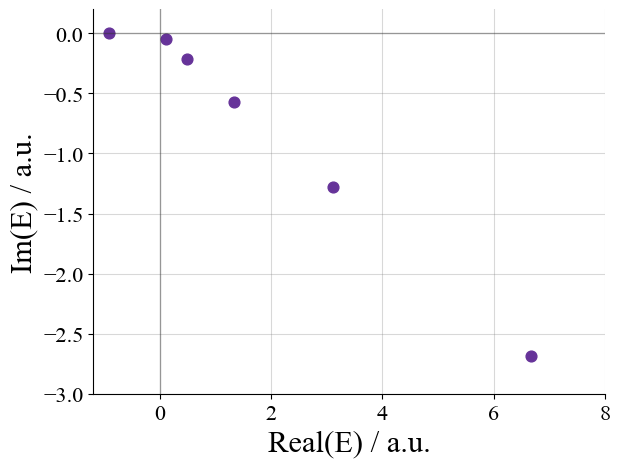

In [71]:

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]


reals = np.real(res.e_orb)
imags = np.imag(res.e_orb)

fig, ax = plt.subplots(figsize=(6.6, 5))

ax.scatter(reals, imags, s=60, c='rebeccapurple')

ax.axhline(0, color='black', linewidth=1, alpha=0.3)
ax.axvline(0, color='black', linewidth=1, alpha=0.3)

ax.spines[['top', 'right']].set_visible(False)

ax.set_xlabel('Real(E) / a.u.', fontsize=22)
ax.set_ylabel('Im(E) / a.u.', fontsize=22)
ax.tick_params(axis='both', labelsize=16)

ax.grid(True, which='major', color='gray', linestyle='-', alpha=0.3, zorder=0)

plt.xlim([-1.2,8])
plt.ylim([-3,.2])

plt.show()

Now we can calculate theta trajectories with:

In [77]:
from py_mods.src.SCF.CSRHF import rhf_theta_traj, plot_theta_traj

max_theta = 0.13
n_points = 30

cxt.verbose = False
cxt.threshold = 1.75e-8

traj_energies = rhf_theta_traj(max_theta, n_points, cxt)

In [ ]:
ax.set_xlabel('Real(E) / a.u.', fontsize=22)
ax.set_ylabel('Im(E) / a.u.', fontsize=22)
ax.tick_params(axis='both', labelsize=16)


fig, ax = plt.subplots(figsize=(6.6, 5))

# ax.scatter(reals, imags, s=60, c='rebeccapurple')

ax.axhline(0, color='black', linewidth=1, alpha=0.3)
ax.axvline(0, color='black', linewidth=1, alpha=0.3)

ax.spines[['top', 'right']].set_visible(False)

ax.set_xlabel('Real(E) / a.u.', fontsize=22)
ax.set_ylabel('Im(E) / a.u.', fontsize=22)
ax.tick_params(axis='both', labelsize=16)

ax.grid(True, which='major', color='gray', linestyle='-', alpha=0.3, zorder=0)

# plt.xlim([-1.2,8])
# plt.ylim([-3,.2])
plt.show()

In [ ]:
plot_theta_traj(traj_energies[1])

Showing that there is a variation of the imaginary component when changing the $\theta$ value. However there is a positive value of the imaginary component of up to $7.631\cdot 10^ {-7}$:

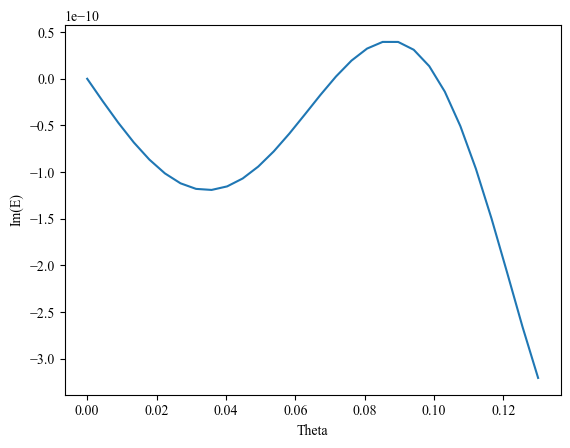

In [73]:
plt.plot(traj_energies[0], [ener.imag for ener in traj_energies[1]])
plt.xlabel("Theta")
plt.ylabel("Im(E)")
# plt.ylim([-1E-6, 1E-6])
plt.show()

However this could be an artifact of the $1s^2$ state. Therefore we have to implement a way to calculate with excited determinants (as there is a very large reference boudy for the $2s^2$ case in He). 

## 2s2 configuration
We implemented a way to determine occupation in the slater determinant. Using this, we can introduce in the HF calculation the occupation vector:
$$
\ket{02000...}
$$

Which what does is that at the moment of building the density matrix, instead of summing over $a$ to $\frac{N}{2}$, it is calculated by:
$$
\mathbf{P}_{\mu \nu} = 2 \sum_{a} L_{\nu a}C_{\mu a} \ket{0}_{a}
$$

Where $\ket{0}_{a}$ is the $a$-th component of the occupation vector. 

In [74]:
cxt.theta = 0
cxt.occupation = np.array([0, 2, 0])
cxt.verbose = True

res = CS_RHF(cxt)

--------------------------------------------------------------------------------------------------------------------------------
|   Iter     |                   E_iter                      |                   Delta_e                   |      norm(e_i)      |
--------------------------------------------------------------------------------------------------------------------------------
      1     0.000000E+00+0.000000E+00j     0.000000E+00+0.000000E+00j     0.0000E+00
      2     -6.963517E-01+0.000000E+00j     -6.963517E-01+0.000000E+00j     2.5910E-01
      3     -7.117037E-01+0.000000E+00j     -1.535201E-02+0.000000E+00j     7.1106E-02
      4     -7.126052E-01+0.000000E+00j     -9.015384E-04+0.000000E+00j     1.2141E-02
      5     -7.126622E-01+0.000000E+00j     -5.696430E-05+0.000000E+00j     4.4089E-03
      6     -7.126659E-01+0.000000E+00j     -3.700337E-06+0.000000E+00j     7.4746E-04
      7     -7.126661E-01+0.000000E+00j     -2.420344E-07+0.000000E+00j     2.7501E-04
    

In the implemented excited-RHF, the $[0,2,0,0,\dots,0]$ configuration resulted in an energy:
$$
E_{2s^{2}}^{RHF/29s}=-0.7127
$$
However using a regular aug-cc-pVQZ results in an energy of:
$$
E_{2s^{2}}^{RHF/aug-cc-pVQZ} = -0.7187
$$
Only a $0.0009$ a.u. of difference with the reference ([Zdanska](https://doi.org/10.1063/1.2110169)):
$$ 
E_{2s^{2}}^{ZDANSKA} =  −0.7196
$$
With an ever larger $aug-cc-pV(5+d)Z$ basis, we get closer to the reference:
$$
E_{2s^{2}}^{RHF/aug-cc-pV(5+d)Z} = -0.7191
$$
Still, it is not the same, but it is close. The real part of the *resonance energy* at the cs-EOM-EE-CCSD level ([Bravaya](https://doi.org/10.1063/1.4795750)) with 125 basis functions is: 
$$
E_{2s ^{2}}^{CCSD/30s15p10d} = −0.7778 
$$
It is true that these are not comparable results, due to both the difference in methods and the scaling. However, it can be seen that it looks to be in the right direction. 

The theta trajectory is:

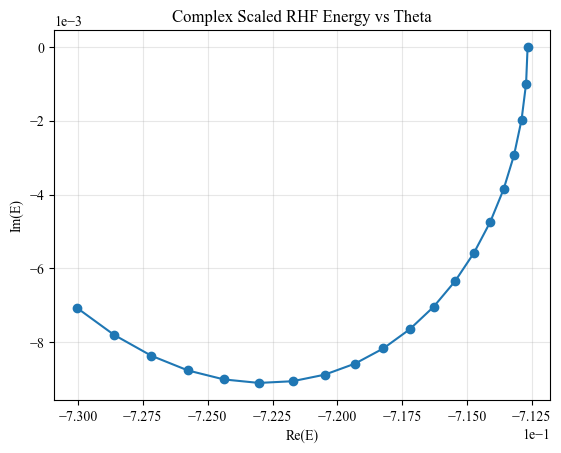

In [75]:
max_theta = 0.3
n_points = 20

cxt.verbose = False

traj_energies = rhf_theta_traj(max_theta, n_points, cxt)
plot_theta_traj(traj_energies[1])

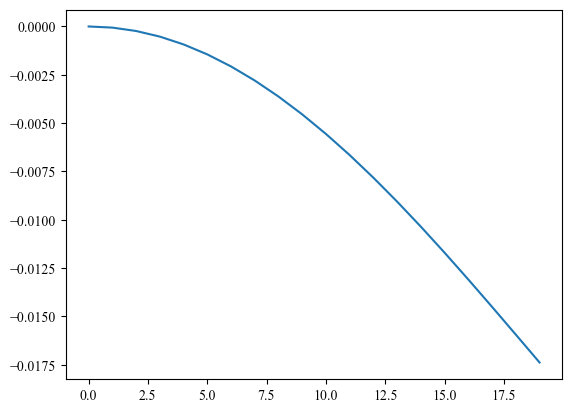

In [76]:
# print(traj_energies[-1])
eners = traj_energies[-1]
re = [e.real for e in eners]
im = [e.imag for e in eners]

plt.plot(re - re[0])
plt.show()

In our case, trying with different basis, the summary of theta-trajectories in the $0 \le \theta \le 0.3$ is:

|Basis             |Number of basis|Energy at $\theta = 0$|                    Range of $Re(E)$|                  Range of $Im(E)$|
|------------------|---------------|----------------------|------------------------------------|----------------------------------|
|$29s$             | $29$          |$-0.7127$             | $(0,-2\cdot 10^{-2})$              |$(0,-9\cdot 10^{-3})$|
|$aug-cc-pVQZ$     | $46$          |$-0.7187$             |       $(0,-8\cdot 10^{-4})$        |$(0,-4\cdot 10^{-3})$|
|$aug-cc-pV(5+d)Z$ | $80$          |$-0.7191$             |       $(0,-3\cdot 10^{-4})$        |$(0,-2\cdot 10^{-4})$|

And we can see that in the larger basis limit, the energy change with theta decreases and the lifetime tends to 0. Also we get closer to the reference value. 